In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, transform=transform, download=True)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, transform=transform, download=True)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)
classes = train_dataset.classes

100%|██████████| 170M/170M [00:05<00:00, 33.0MB/s]


In [ ]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 16x16

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)  # 8x8
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x


#  Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

#  Training Loop
print("Training CNN without data augmentation...")
for epoch in range(15):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total += labels.size(0)

    acc = 100 * correct / total
    print(f"Epoch {epoch+1}: Loss={running_loss:.4f}, Accuracy={acc:.2f}%")
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

test_acc = 100 * correct / total
print(f"\n Test Accuracy (no augmentation): {test_acc:.2f}%")

Training CNN without data augmentation...
Epoch 1: Loss=643.6966, Accuracy=40.91%
Epoch 2: Loss=447.7947, Accuracy=59.01%
Epoch 3: Loss=387.4799, Accuracy=64.97%
Epoch 4: Loss=349.2669, Accuracy=68.66%
Epoch 5: Loss=322.7161, Accuracy=70.67%
Epoch 6: Loss=301.0925, Accuracy=72.77%
Epoch 7: Loss=282.1855, Accuracy=74.42%
Epoch 8: Loss=260.0637, Accuracy=76.21%
Epoch 9: Loss=242.1982, Accuracy=77.98%
Epoch 10: Loss=225.0793, Accuracy=79.49%
Epoch 11: Loss=212.1296, Accuracy=80.54%
Epoch 12: Loss=197.4475, Accuracy=81.85%
Epoch 13: Loss=185.7510, Accuracy=82.59%
Epoch 14: Loss=170.8206, Accuracy=84.11%
Epoch 15: Loss=161.8160, Accuracy=84.88%

 Test Accuracy (no augmentation): 74.26%


In [ ]:
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

test_acc = 100 * correct / total
print(f"\n Test Accuracy (no augmentation): {test_acc:.2f}%")


 Test Accuracy (no augmentation): 74.26%


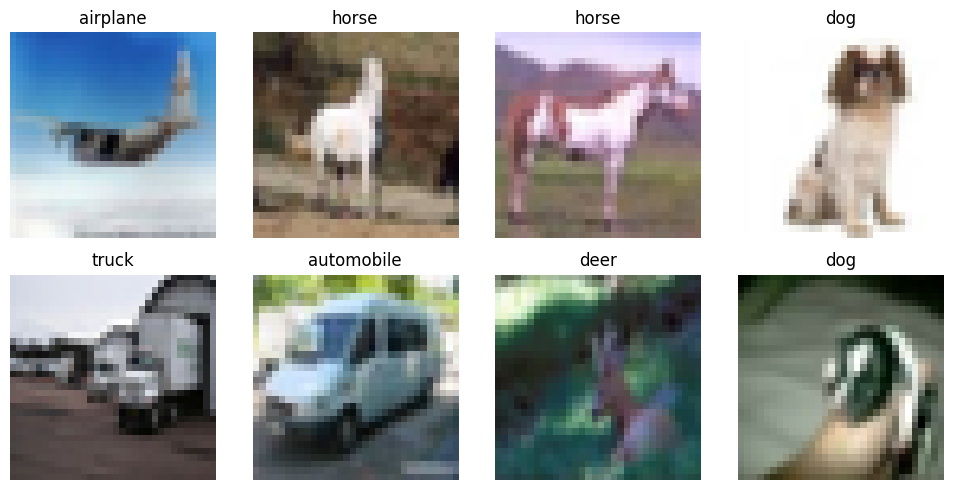

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def imshow_grid(images, labels, class_names):
    images = images[:8]  # Show first 8 images
    labels = labels[:8]

    images = images.numpy()
    fig, axes = plt.subplots(2, 4, figsize=(10, 5))
    fig.subplots_adjust(hspace=0.5)

    for i, ax in enumerate(axes.flat):
        img = np.transpose(images[i], (1, 2, 0))  # CHW → HWC
        ax.imshow(img)
        ax.set_title(class_names[labels[i]])
        ax.axis('off')

    plt.tight_layout()
    plt.show()
# One batch from loader
dataiter = iter(train_loader)
images, labels = next(dataiter)

# Show images
imshow_grid(images, labels, classes)
